In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
include_flag_array = True

In [3]:
from IPython.display import display

from pathlib import Path
from functools import partial

import numpy as np
import pandas as pd

from scan_statistics import (
    load_transmission,
    detect_atm_ranges,
    compute_scan_statistics_scores,
    Input,
)

In [4]:
trans_freq, trans_vals = load_transmission("data/full_spectrum.gzip")


def get_scan_statistics_columns(
    row: pd.Series, trans_freq: np.ndarray, trans_vals: np.ndarray
) -> pd.DataFrame:
    amp = row["amplitude"]
    freq = row["frequency_array"] / 1e9
    flag = row["flag_array"] if include_flag_array else np.zeros_like(freq, dtype=bool)

    atm_ranges = detect_atm_ranges(freq, trans_freq, trans_vals)
    output = dict(atmospheric_interference=atm_ranges)

    scan_stats_input = Input(
        amplitude=amp,
        frequency=freq,
        flag_array=flag,
        atm_ranges=atm_ranges,
    )
    scan_stats_output = compute_scan_statistics_scores({"key": scan_stats_input})
    for scan_mode, scan_output in scan_stats_output["key"].items():
        output[f"score_{scan_mode}"] = scan_output.score
        output[f"win_{scan_mode}_start"] = scan_output.win_start
        output[f"win_{scan_mode}_end"] = scan_output.win_end
        # output[f"segment_width_{scan_mode}"] = abs(
        #     freq[scan_output.win_end] - freq[scan_output.win_start]
        # )
    return pd.Series(output)

In [5]:
if include_flag_array:
    df_parquet = pd.read_parquet("data/QA2_WithFlags.parquet")
else:
    df_parquet = pd.read_parquet("data/QA2_WithoutFlags.parquet")
df_parquet = df_parquet[
    [
        "eb_uid",
        "spw_name_ms",
        "antenna_name",
        "pol_id",
        "amplitude",
        "frequency_array",
        "flag_array",
        "receiver_band",
        "atmospheric_interference",
        "score_masked",
        "score_unmasked",
        "score_fixed",
        "win_masked_start",
        "win_masked_end",
        "win_unmasked_start",
        "win_unmasked_end",
        "win_fixed_start",
        "win_fixed_end",
    ]
]

In [ ]:
keyed_input = {}
for idx, row in df_parquet.iterrows():
    amp = row["amplitude"]
    freq = row["frequency_array"] / 1e9
    flag = row["flag_array"] if include_flag_array else np.zeros_like(freq, dtype=bool)
    atm_ranges = detect_atm_ranges(freq, trans_freq, trans_vals)
    keyed_input[str(idx)] = Input(amplitude=amp, frequency=freq,
                                   flag_array=flag, atm_ranges=atm_ranges)

# Run all rows in parallel:
computed_scan_statistics = compute_scan_statistics_scores(keyed_input, max_workers=-1)

In [6]:
keyed_input = {}
atm_cache = {}
for idx, row in df_parquet.iterrows():
    amp = row["amplitude"]
    freq = row["frequency_array"] / 1e9
    flag = row["flag_array"] if include_flag_array else np.zeros_like(freq, dtype=bool)
    atm_ranges = detect_atm_ranges(freq, trans_freq, trans_vals)
    atm_cache[idx] = atm_ranges
    keyed_input[str(idx)] = Input(
        amplitude=amp, frequency=freq, flag_array=flag, atm_ranges=atm_ranges,
    )

In [ ]:
records = []
for idx in df_parquet.index:
    scan_result = computed_scan_statistics.get(str(idx), {})
    rec = {"atmospheric_interference": atm_cache.get(idx, [])}
    for scan_mode in ["masked", "unmasked", "fixed"]:
        out = scan_result.get(scan_mode)
        if out is not None:
            rec[f"score_{scan_mode}"] = out.score
            rec[f"win_{scan_mode}_start"] = out.win_start
            rec[f"win_{scan_mode}_end"] = out.win_end
        else:
            rec[f"score_{scan_mode}"] = np.nan
            rec[f"win_{scan_mode}_start"] = np.nan
            rec[f"win_{scan_mode}_end"] = np.nan
    records.append(rec)

computed_scan_statistics = pd.DataFrame(records, index=df_parquet.index)

In [10]:
merged = df_parquet.merge(
    computed_scan_statistics,
    left_index=True,
    right_index=True,
    how="outer",
    suffixes=("_original", "_computed"),
)

In [ ]:
merged.to_parquet("data/QA2_result_comparison.parquet", engine='pyarrow', compression="zstd")

In [9]:
merged = pd.read_parquet("data/QA2_result_comparison.parquet")

In [11]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86938 entries, 0 to 86937
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   eb_uid                             86938 non-null  object 
 1   spw_name_ms                        86938 non-null  object 
 2   antenna_name                       86938 non-null  object 
 3   pol_id                             86938 non-null  object 
 4   amplitude                          86938 non-null  object 
 5   frequency_array                    86938 non-null  object 
 6   flag_array                         86938 non-null  object 
 7   receiver_band                      86938 non-null  object 
 8   atmospheric_interference_original  86938 non-null  object 
 9   score_masked_original              86938 non-null  float64
 10  score_unmasked_original            86938 non-null  float64
 11  score_fixed_original               86938 non-null  flo

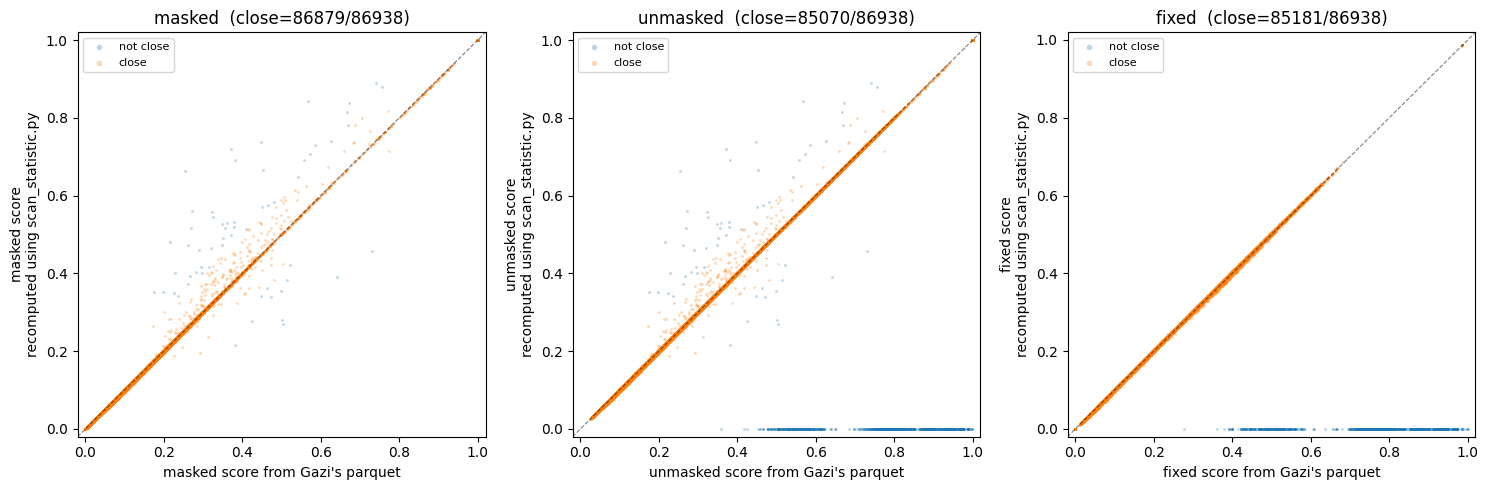

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    ("score_masked_original",   "score_masked_computed",   "score_masked_is_close",   "masked"),
    ("score_unmasked_original", "score_unmasked_computed", "score_unmasked_is_close", "unmasked"),
    ("score_fixed_original",    "score_fixed_computed",    "score_fixed_is_close",    "fixed"),
]

for ax, (orig_col, comp_col, close_col, label) in zip(axes, pairs):
    x = merged[orig_col].values
    y = merged[comp_col].values
    close = merged[close_col].values

    ax.scatter(x[~close], y[~close], s=4, alpha=0.3, linewidths=0, label="not close")
    ax.scatter(x[ close], y[ close], s=4, alpha=0.3, linewidths=0, label="close")

    lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
    ax.plot(lims, lims, "k--", lw=0.8, alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f"{label} score from Gazi's parquet")
    ax.set_ylabel(f"{label} score\nrecomputed using scan_statistic.py")
    ax.set_title(f"{label}  (close={close.sum()}/{len(close)})")
    ax.legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.savefig("score_scatter.png", dpi=150)
plt.show()

In [18]:
bad_all = []
for mode in ["masked", "unmasked", "fixed"]:
    orig  = f"score_{mode}_original"
    comp  = f"score_{mode}_computed"
    close = f"score_{mode}_is_close"
    sub = merged[
        (merged[comp] != 0) &
        (~merged[close])
    ][["eb_uid", "antenna_name", "spw_name_ms", "pol_id", "flag_array",
       orig, comp,
       f"win_{mode}_start_original", f"win_{mode}_end_original",
       f"win_{mode}_start_computed", f"win_{mode}_end_computed"]
    ].copy()
    sub["mode"] = mode
    sub["diff"] = sub[comp] - sub[orig]
    sub = sub.rename(columns={orig: "score_original", comp: "score_computed"})
    bad_all.append(sub)
    print(f"{mode}: {len(sub)} rows non-zero and not close")

bad = pd.concat(bad_all, ignore_index=True)
print(f"\nTotal: {len(bad)}\n")
print(bad.groupby("mode")["diff"].describe().round(4))

masked: 59 rows non-zero and not close
unmasked: 59 rows non-zero and not close
fixed: 0 rows non-zero and not close

Total: 118

          count    mean     std    min     25%    50%     75%   max
mode                                                               
masked     59.0  0.1021  0.1538 -0.274  0.1055  0.129  0.1709  0.41
unmasked   59.0  0.1021  0.1538 -0.274  0.1055  0.129  0.1709  0.41


In [19]:
for mode in ["masked", "unmasked", "fixed"]:
    sub = bad[bad["mode"] == mode]
    print(f"\n{'='*70}")
    print(f"  {mode.upper()}  ({len(sub)} rows)")
    print(f"{'='*70}")
    print(sub[["eb_uid", "antenna_name", "spw_name_ms", "pol_id",
               "score_original", "score_computed", "diff", "flag_array"]].to_string(index=False))


  MASKED  (59 rows)
                    eb_uid antenna_name spw_name_ms pol_id  score_original  score_computed      diff                                                                                                       flag_array
   uid://A002/Xfacb6a/Xbdf         CM03          16      Y        0.214652        0.480463  0.265811 [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]
   uid://A002/Xfacb6a/Xbdf         CM12          16      Y        0.378793        0.518416  0.139623 [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]
   uid://A002/Xfacb6a/Xbdf         CM07          18      X        0.450743        0.571845  0.121102 [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]
   uid://A002/Xfacb6a/Xbdf         CM10          18      X        0.471797        0.339178 -0.132619 [False, False, False, 

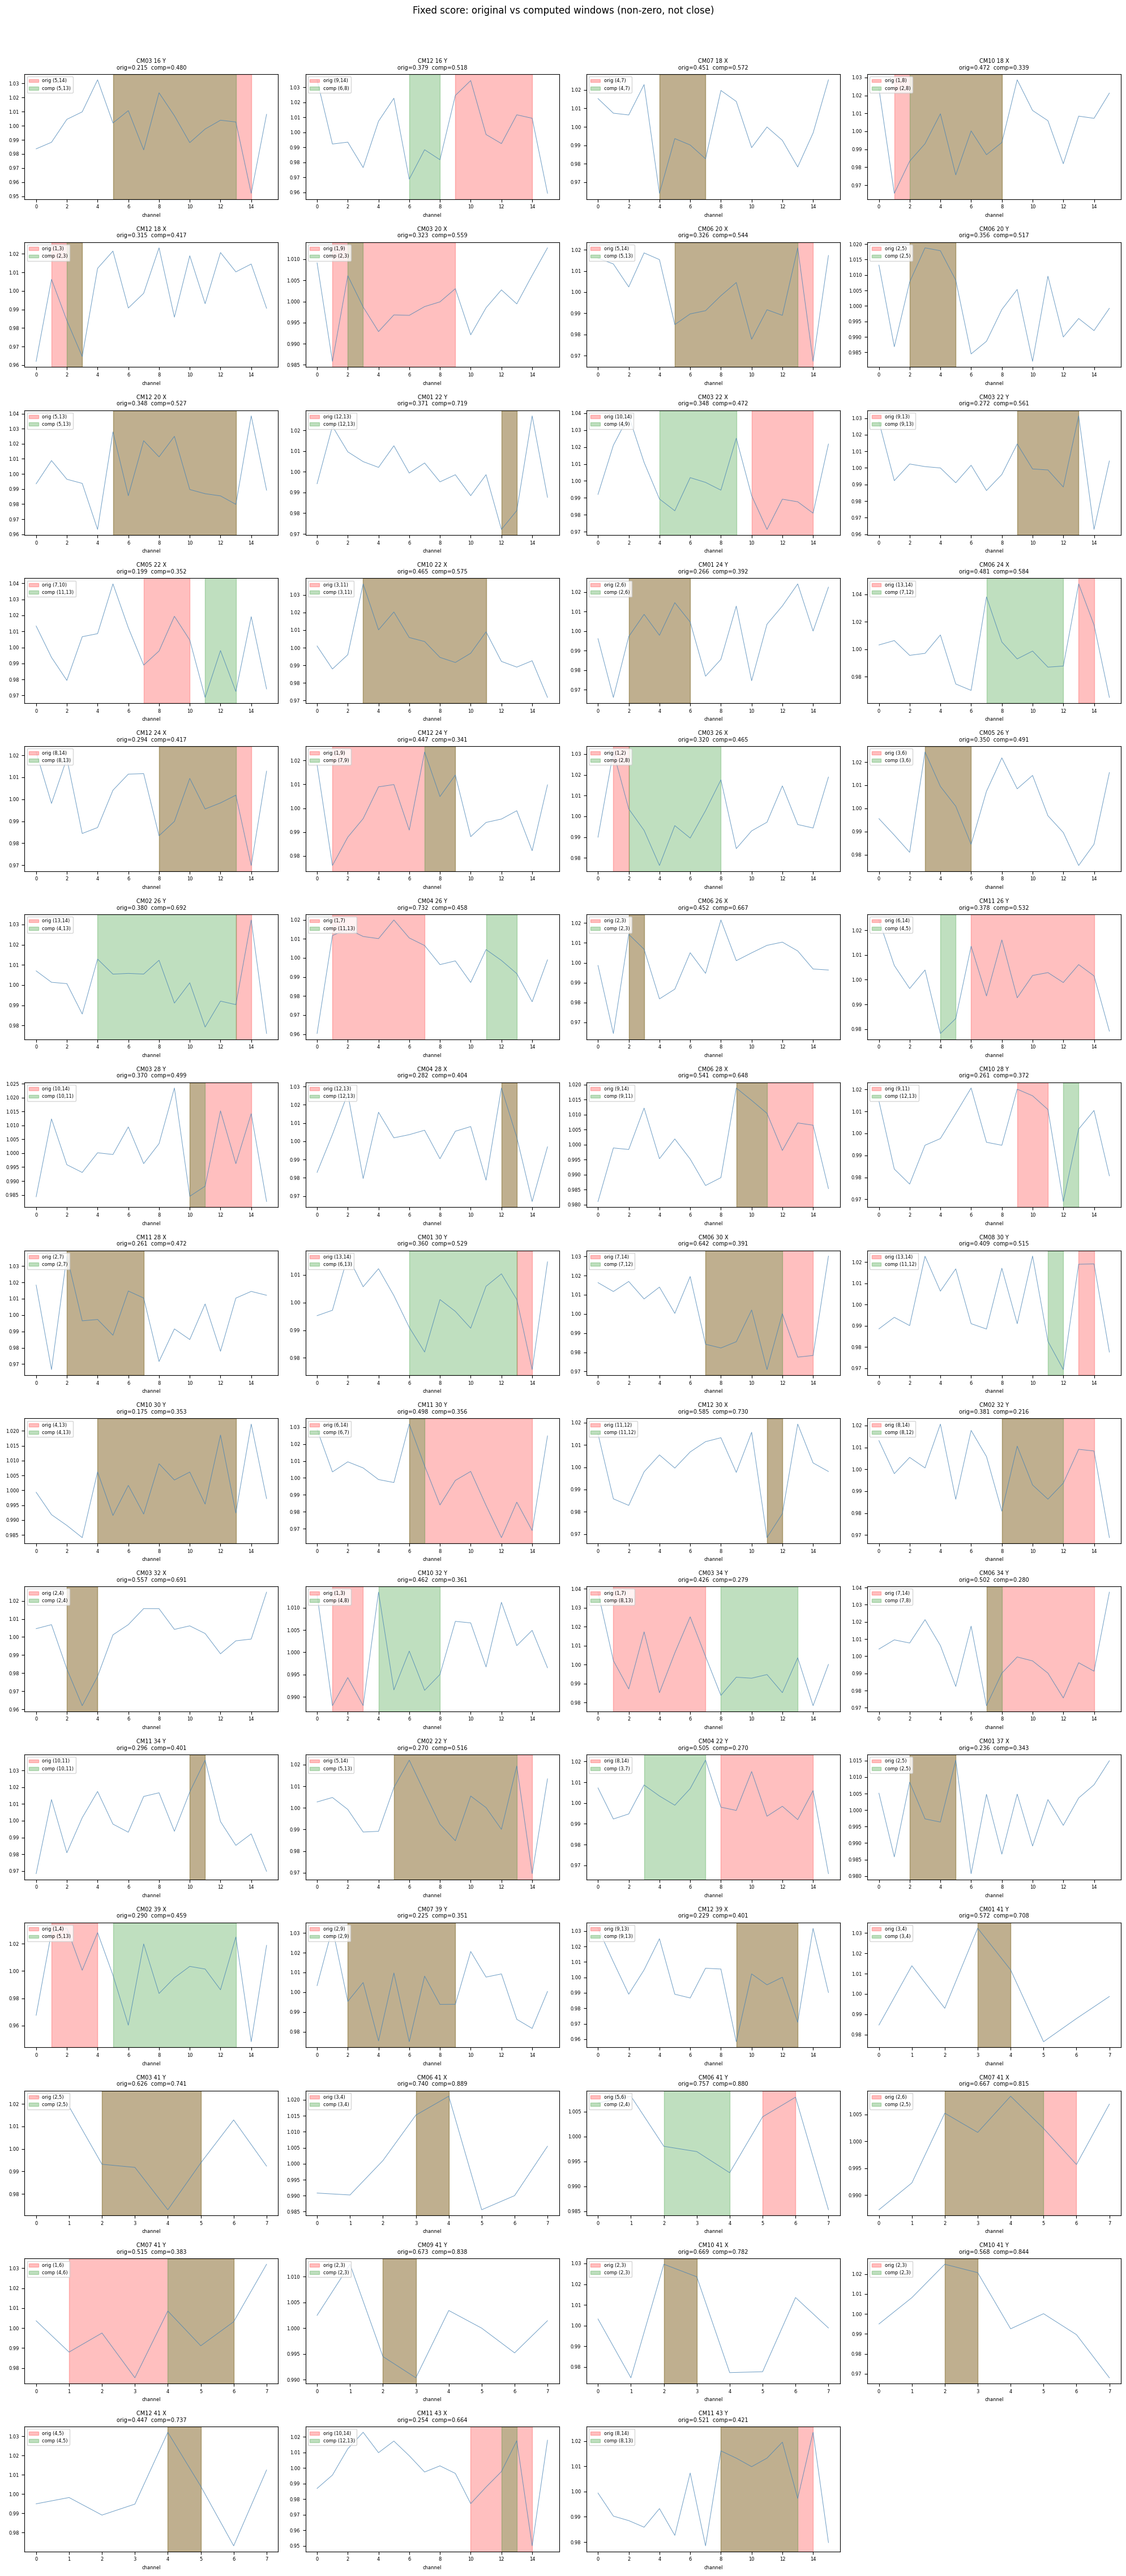

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# get the 59 bad rows
mode = "unmasked"
bad_rows = bad[bad["mode"] == mode]   # adjust mode if needed

n = len(bad_rows)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3))
axes = axes.flatten()

for i, (_, row) in enumerate(bad_rows.iterrows()):
    # get the actual spectrum
    spec_row = merged[
        (merged["eb_uid"]        == row["eb_uid"]) &
        (merged["antenna_name"]  == row["antenna_name"]) &
        (merged["spw_name_ms"]   == row["spw_name_ms"]) &
        (merged["pol_id"]        == row["pol_id"])
    ].iloc[0]

    amp  = np.asarray(spec_row["amplitude"], dtype=np.float64).ravel()
    n_ch = len(amp)
    ax   = axes[i]

    ax.plot(amp, color="steelblue", lw=0.7, alpha=0.8)

    # original window
    a0, b0 = int(row[f"win_{mode}_start_original"]), int(row[f"win_{mode}_end_original"])
    ax.axvspan(a0, b0, color="red",   alpha=0.25, label=f"orig ({a0},{b0})")

    a1, b1 = int(row[f"win_{mode}_start_computed"]), int(row[f"win_{mode}_end_computed"])
    ax.axvspan(a1, b1, color="green", alpha=0.25, label=f"comp ({a1},{b1})")

    ax.set_title(
        f"{row['antenna_name']} {row['spw_name_ms']} {row['pol_id']}\n"
        f"orig={row['score_original']:.3f}  comp={row['score_computed']:.3f}",
        fontsize=7
    )
    ax.legend(fontsize=6, loc="upper left")
    ax.set_xlabel("channel", fontsize=6)
    ax.tick_params(labelsize=6)

# hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Fixed score: original vs computed windows (non-zero, not close)", y=1.01)
plt.tight_layout()
plt.savefig("fixed_score_outliers.png", dpi=120, bbox_inches="tight")
plt.show()

rows found: 1


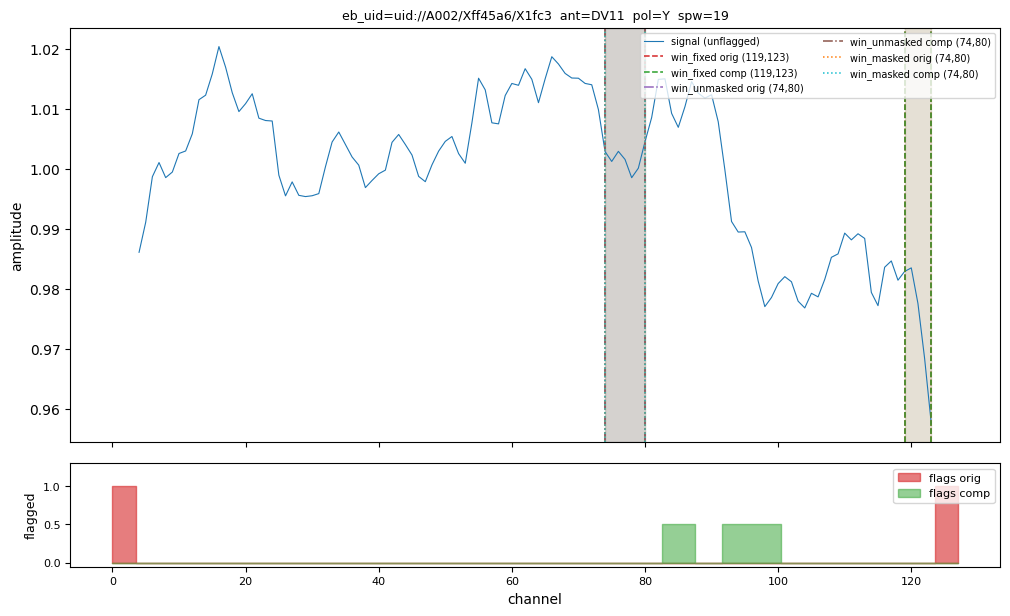

win_fixed       orig=0.4991  comp=0.4995  close=True
win_unmasked    orig=0.1006  comp=0.0998  close=True
win_masked      orig=0.1006  comp=0.0998  close=True


In [34]:
# --- find the row ---
mask = (
    (merged["eb_uid"]       == "uid://A002/Xff45a6/X1fc3") &
    (merged["antenna_name"] == "DV11") &
    (merged["pol_id"]       == "Y") &
    (merged["spw_name_ms"]  == "19")
)
row = merged[mask]
print(f"rows found: {len(row)}")
if len(row) == 0:
    raise ValueError("No matching row")
row = row.iloc[0]

amp        = np.asarray(row["amplitude"],       dtype=np.float64).ravel()
freq       = np.asarray(row["frequency_array"], dtype=np.float64).ravel()
flags_orig = np.asarray(row["flag_array"],      dtype=bool).ravel()
n  = len(amp)
ch = np.arange(n)

flags_comp = np.zeros(n, dtype=bool)
atm = row["atmospheric_interference_computed"]
if atm is not None and len(atm) > 0:
    for item in atm:
        flags_comp[int(item[0]):int(item[1])+1] = True

amp_plot = amp.copy().astype(float)
amp_plot[flags_orig] = np.nan

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={"height_ratios": [4, 1]})
fig.subplots_adjust(hspace=0.08)

ax = axes[0]
ax.plot(ch, amp_plot, lw=0.8, color="#1f77b4", label="signal (unflagged)")

windows = [
    ("win_fixed",    "#d62728", "#2ca02c",  "--"),
    ("win_unmasked", "#9467bd", "#8c564b",  "-."),
    ("win_masked",   "#ff7f0e", "#17becf",  ":"),
]

for win_key, col_orig, col_comp, ls in windows:
    for col, key, label in [(col_orig, "original", "orig"),
                            (col_comp, "computed", "comp")]:
        a = int(row[f"{win_key}_start_{key}"])
        b = int(row[f"{win_key}_end_{key}"])
        ax.axvspan(a, b, alpha=0.10, color=col)
        ax.axvline(a, color=col, lw=1.1, ls=ls,
                   label=f"{win_key} {label} ({a},{b})")
        ax.axvline(b, color=col, lw=1.1, ls=ls)

ax.set_ylabel("amplitude", fontsize=10)
ax.legend(fontsize=7, loc="upper right", ncol=2)
ax.set_title(
    f"eb_uid={row['eb_uid']}  ant={row['antenna_name']}  "
    f"pol={row['pol_id']}  spw={row['spw_name_ms']}",
    fontsize=9)

ax2 = axes[1]
ax2.fill_between(ch, flags_orig.astype(int), step="mid",
                 color="#d62728", alpha=0.6, label="flags orig")
ax2.fill_between(ch, flags_comp.astype(int) * 0.5, step="mid",
                 color="#2ca02c", alpha=0.5, label="flags comp")
ax2.set_ylabel("flagged", fontsize=9)
ax2.set_ylim(-0.05, 1.3)
ax2.set_xlabel("channel", fontsize=10)
ax2.legend(fontsize=8, loc="upper right")
ax2.tick_params(labelsize=8)

plt.savefig("signal_debug.png", dpi=150, bbox_inches="tight")
plt.show()

for win_key in ("win_fixed", "win_unmasked", "win_masked"):
    sc_o = row[f"score_{win_key.split('_')[1]}_original"]
    sc_c = row[f"score_{win_key.split('_')[1]}_computed"]
    ok   = row[f"score_{win_key.split('_')[1]}_is_close"]
    print(f"{win_key:<14}  orig={sc_o:.4f}  comp={sc_c:.4f}  close={ok}")

In [33]:
mask = (
    (merged["eb_uid"]       == "uid://A002/Xff45a6/X1fc3") &
    (merged["antenna_name"] == "DV11") &
    (merged["pol_id"]       == "Y") &
    (merged["spw_name_ms"]  == "19")
)
row = merged[mask].iloc[0]
print("score_masked_original :", row["score_masked_original"])
print("score_masked_computed :", row["score_masked_computed"])
print("win_masked original   :", row["win_masked_start_original"], row["win_masked_end_original"])
print("win_masked computed   :", row["win_masked_start_computed"], row["win_masked_end_computed"])
print("flagged channels      :", flags_orig.sum())
print("keep_masked size      :", flags_orig.sum(), "  (the search space for the masked sweep)")

score_masked_original : 0.10061519562122134
score_masked_computed : 0.09983197189481485
win_masked original   : 74 80
win_masked computed   : 74 80
flagged channels      : 8
keep_masked size      : 8   (the search space for the masked sweep)


In [10]:
from IPython.display import display

# Some scores are wrong
for scan_mode in ["masked", "unmasked", "fixed"]:
    merged[f"score_{scan_mode}_is_close"] = merged.apply(
        lambda row: np.isclose(
            row[f"score_{scan_mode}_original"],
            row[f"score_{scan_mode}_computed"],
            atol=1e-1,
        ),
        axis=1,
    )
    print(merged.dropna()[f"score_{scan_mode}_is_close"].value_counts())
    display(
        merged.dropna()
        .query(f"not score_{scan_mode}_is_close")
        # .query('eb_uid == "uid://A002/X1041199/X82f" and antenna_name == "DA46" and spw_name_ms == "27"')
        .head(10)[["eb_uid", "spw_name_ms", "antenna_name", "pol_id", f"score_{scan_mode}_original", f"score_{scan_mode}_computed"]]
    )

score_masked_is_close
True     86879
False       59
Name: count, dtype: int64


,eb_uid,spw_name_ms,antenna_name,pol_id,score_masked_original,score_masked_computed
3859,uid://A002/Xfacb6a/Xbdf,16,CM03,Y,0.214652,0.480463
3873,uid://A002/Xfacb6a/Xbdf,16,CM12,Y,0.378793,0.518416
3882,uid://A002/Xfacb6a/Xbdf,18,CM07,X,0.450743,0.571845
3886,uid://A002/Xfacb6a/Xbdf,18,CM10,X,0.471797,0.339178
3890,uid://A002/Xfacb6a/Xbdf,18,CM12,X,0.315470,0.417444
3894,uid://A002/Xfacb6a/Xbdf,20,CM03,X,0.323060,0.558654
3898,uid://A002/Xfacb6a/Xbdf,20,CM06,X,0.325804,0.544071
3899,uid://A002/Xfacb6a/Xbdf,20,CM06,Y,0.355814,0.516605
3908,uid://A002/Xfacb6a/Xbdf,20,CM12,X,0.348286,0.526999
3911,uid://A002/Xfacb6a/Xbdf,22,CM01,Y,0.371097,0.719325


score_unmasked_is_close
True     85070
False     1868
Name: count, dtype: int64


,eb_uid,spw_name_ms,antenna_name,pol_id,score_unmasked_original,score_unmasked_computed
10,uid://A002/X1020da2/X98d1,5,DA48,X,0.841067,0.0
11,uid://A002/X1020da2/X98d1,5,DA48,Y,0.753614,0.0
66,uid://A002/X1020da2/X98d1,5,DV16,X,0.841067,0.0
67,uid://A002/X1020da2/X98d1,5,DV16,Y,0.753614,0.0
94,uid://A002/X1020da2/X98d1,7,DA48,X,0.833530,0.0
95,uid://A002/X1020da2/X98d1,7,DA48,Y,0.806917,0.0
150,uid://A002/X1020da2/X98d1,7,DV16,X,0.833530,0.0
151,uid://A002/X1020da2/X98d1,7,DV16,Y,0.806917,0.0
178,uid://A002/X1020da2/X98d1,11,DA48,X,0.820874,0.0
179,uid://A002/X1020da2/X98d1,11,DA48,Y,0.836431,0.0


score_fixed_is_close
True     85181
False     1757
Name: count, dtype: int64


,eb_uid,spw_name_ms,antenna_name,pol_id,score_fixed_original,score_fixed_computed
10,uid://A002/X1020da2/X98d1,5,DA48,X,0.830505,0.0
11,uid://A002/X1020da2/X98d1,5,DA48,Y,0.740102,0.0
66,uid://A002/X1020da2/X98d1,5,DV16,X,0.830505,0.0
67,uid://A002/X1020da2/X98d1,5,DV16,Y,0.740102,0.0
94,uid://A002/X1020da2/X98d1,7,DA48,X,0.825567,0.0
95,uid://A002/X1020da2/X98d1,7,DA48,Y,0.784371,0.0
150,uid://A002/X1020da2/X98d1,7,DV16,X,0.825567,0.0
151,uid://A002/X1020da2/X98d1,7,DV16,Y,0.784371,0.0
178,uid://A002/X1020da2/X98d1,11,DA48,X,0.809345,0.0
179,uid://A002/X1020da2/X98d1,11,DA48,Y,0.824959,0.0


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Build a unified mismatch dataframe ──
SCORE_ATOL = 1e-6

mismatch_flags = []
for mode in ["masked", "unmasked", "fixed"]:
    mismatch_flags.append(
        ~merged[f"score_{mode}_is_close"]
    )

merged["any_mismatch"] = mismatch_flags[0] | mismatch_flags[1] | mismatch_flags[2]
mismatched = merged[merged["any_mismatch"]].dropna(subset=["amplitude"]).copy()
mismatched = mismatched.reset_index(drop=True)

print(f"Total rows: {len(merged)}")
print(f"Mismatched rows: {len(mismatched)}")
print()
display(
    mismatched[
        ["eb_uid", "antenna_name", "spw_name_ms", "pol_id", "receiver_band"]
        + [c for c in mismatched.columns if "is_close" in c or "is_same" in c]
    ].head(20)
)

Total rows: 86938
Mismatched rows: 1868



,eb_uid,antenna_name,spw_name_ms,pol_id,receiver_band,score_masked_is_close,score_unmasked_is_close,score_fixed_is_close
0,uid://A002/X1020da2/X98d1,DA48,5,X,ALMA_RB_03,True,False,False
1,uid://A002/X1020da2/X98d1,DA48,5,Y,ALMA_RB_03,True,False,False
2,uid://A002/X1020da2/X98d1,DV16,5,X,ALMA_RB_03,True,False,False
3,uid://A002/X1020da2/X98d1,DV16,5,Y,ALMA_RB_03,True,False,False
4,uid://A002/X1020da2/X98d1,DA48,7,X,ALMA_RB_03,True,False,False
5,uid://A002/X1020da2/X98d1,DA48,7,Y,ALMA_RB_03,True,False,False
6,uid://A002/X1020da2/X98d1,DV16,7,X,ALMA_RB_03,True,False,False
7,uid://A002/X1020da2/X98d1,DV16,7,Y,ALMA_RB_03,True,False,False
8,uid://A002/X1020da2/X98d1,DA48,11,X,ALMA_RB_03,True,False,False
9,uid://A002/X1020da2/X98d1,DA48,11,Y,ALMA_RB_03,True,False,False


In [ ]:
def _contiguous_ranges(mask):
    """Yield (start, end) for contiguous True runs in a bool array."""
    ranges = []
    in_run = False
    for i, v in enumerate(mask):
        if v and not in_run:
            start = i
            in_run = True
        elif not v and in_run:
            ranges.append((start, i - 1))
            in_run = False
    if in_run:
        ranges.append((start, len(mask) - 1))
    return ranges


def plot_mismatch(idx: int, mismatched_df=mismatched):
    """
    Plot a single mismatched row by its index in the mismatched dataframe.
    Shows spectrum with original (blue) vs computed (red) windows for all 3 modes.
    """
    row = mismatched_df.iloc[idx]
    amp = np.array(row["amplitude"])
    freq = np.array(row["frequency_array"]) / 1e9
    flags = np.array(row["flag_array"]) if row["flag_array"] is not None else np.zeros_like(amp, dtype=bool)
    for col in ["atmospheric_interference_original", "atmospheric_interference_computed", "atmospheric_interference"]:
        atm = row.get(col, None)
        if atm is not None and hasattr(atm, '__len__') and len(atm) > 0:
            break
    else:
        atm = []

    title_id = (
        f"{row['eb_uid']}  ant={row['antenna_name']}  "
        f"spw={row['spw_name_ms']}  pol={row['pol_id']}  band={row['receiver_band']}"
    )

    modes = ["masked", "unmasked", "fixed"]
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig.suptitle(f"Mismatch idx={idx}\n{title_id}\nn={len(amp)}", fontsize=11, y=0.98)

    for ax, mode in zip(axes, modes):
        ax.plot(freq, amp, linewidth=0.4, color="#333", alpha=0.8, label="spectrum")

        # Flagged channels (grey)
        if flags is not None and flags.any():
            for s, e in _contiguous_ranges(flags.astype(bool)):
                ax.axvspan(freq[s], freq[min(e, len(freq)-1)], color="grey", alpha=0.15, zorder=0)

        # Atmospheric interference (yellow)
        for s, e in atm:
            if s < len(freq) and e < len(freq):
                ax.axvspan(freq[s], freq[e], color="gold", alpha=0.20, zorder=0)

        # Original window (blue)
        os_val = row[f"score_{mode}_original"]
        ows = int(row[f"win_{mode}_start_original"])
        owe = int(row[f"win_{mode}_end_original"])
        if 0 <= ows < len(freq) and 0 <= owe < len(freq) and owe >= ows:
            ax.axvspan(freq[ows], freq[owe], color="blue", alpha=0.18,
                       label=f"original [{ows},{owe}] sc={os_val:.4f}")

        # Computed window (red)
        cs_val = row[f"score_{mode}_computed"]
        cws = int(row[f"win_{mode}_start_computed"])
        cwe = int(row[f"win_{mode}_end_computed"])
        if 0 <= cws < len(freq) and 0 <= cwe < len(freq) and cwe >= cws:
            ax.axvspan(freq[cws], freq[cwe], color="red", alpha=0.18,
                       label=f"computed [{cws},{cwe}] sc={cs_val:.4f}")

        score_match = np.isclose(os_val, cs_val, atol=SCORE_ATOL)
        win_match = (ows == cws) and (owe == cwe)
        status = "✓" if (score_match and win_match) else "✗"
        ax.set_title(f"{mode}  {status}   Δscore={abs(os_val - cs_val):.6f}   "
                     f"Δstart={abs(ows - cws)}   Δend={abs(owe - cwe)}",
                     fontsize=10, loc="left")
        ax.legend(fontsize=8, loc="upper right")
        ax.set_ylabel("Amplitude")

    axes[-1].set_xlabel("Frequency (GHz)")
    plt.tight_layout()
    plt.show()


def plot_mismatch_by_df_index(orig_idx: int):
    """Plot by the original merged dataframe index."""
    row = merged.loc[orig_idx]
    tmp = pd.DataFrame([row]).reset_index(drop=True)
    plot_mismatch(0, mismatched_df=tmp)

In [ ]:
import os

save_dir = "images/mismatch_plots"
os.makedirs(save_dir, exist_ok=True)

for i in range(len(mismatched)):
    orig_idx = mismatched.index[i] if mismatched.index.name is None else i
    # get the original merged index before reset_index
    # since we did reset_index(drop=True), recover it from merged
    orig_idx = merged[merged["any_mismatch"]].dropna(subset=["amplitude"]).index[i]

    row = mismatched.iloc[i]
    amp = np.array(row["amplitude"])
    freq = np.array(row["frequency_array"]) / 1e9
    flags = np.array(row["flag_array"]) if row["flag_array"] is not None else np.zeros_like(amp, dtype=bool)

    for col in ["atmospheric_interference_original", "atmospheric_interference_computed", "atmospheric_interference"]:
        atm = row.get(col, None)
        if atm is not None and hasattr(atm, '__len__') and len(atm) > 0:
            break
    else:
        atm = []

    title_id = (
        f"{row['eb_uid']}  ant={row['antenna_name']}  "
        f"spw={row['spw_name_ms']}  pol={row['pol_id']}  band={row['receiver_band']}"
    )

    modes = ["masked", "unmasked", "fixed"]
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig.suptitle(f"Row {orig_idx}\n{title_id}\nn={len(amp)}", fontsize=11, y=0.98)

    for ax, mode in zip(axes, modes):
        ax.plot(freq, amp, linewidth=0.4, color="#333", alpha=0.8, label="spectrum")

        if flags is not None and flags.any():
            for s, e in _contiguous_ranges(flags.astype(bool)):
                ax.axvspan(freq[s], freq[min(e, len(freq)-1)], color="grey", alpha=0.15, zorder=0)

        for s, e in atm:
            if s < len(freq) and e < len(freq):
                ax.axvspan(freq[s], freq[e], color="gold", alpha=0.20, zorder=0)

        os_val = row[f"score_{mode}_original"]
        ows = int(row[f"win_{mode}_start_original"])
        owe = int(row[f"win_{mode}_end_original"])
        if 0 <= ows < len(freq) and 0 <= owe < len(freq) and owe >= ows:
            ax.axvspan(freq[ows], freq[owe], color="blue", alpha=0.18,
                       label=f"original [{ows},{owe}] sc={os_val:.4f}")

        cs_val = row[f"score_{mode}_computed"]
        cws = int(row[f"win_{mode}_start_computed"])
        cwe = int(row[f"win_{mode}_end_computed"])
        if 0 <= cws < len(freq) and 0 <= cwe < len(freq) and cwe >= cws:
            ax.axvspan(freq[cws], freq[cwe], color="red", alpha=0.18,
                       label=f"computed [{cws},{cwe}] sc={cs_val:.4f}")

        score_match = np.isclose(os_val, cs_val, atol=SCORE_ATOL)
        win_match = (ows == cws) and (owe == cwe)
        status = "✓" if (score_match and win_match) else "✗"
        ax.set_title(f"{mode}  {status}   Δscore={abs(os_val - cs_val):.6f}   "
                     f"Δstart={abs(ows - cws)}   Δend={abs(owe - cwe)}",
                     fontsize=10, loc="left")
        ax.legend(fontsize=8, loc="upper right")
        ax.set_ylabel("Amplitude")

    axes[-1].set_xlabel("Frequency (GHz)")
    plt.tight_layout()
    fig.savefig(os.path.join(save_dir, f"row_{orig_idx}.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)

    if (i + 1) % 50 == 0:
        print(f"  saved {i + 1}/{len(mismatched)}")

print(f"Done — {len(mismatched)} plots saved to {save_dir}/")

In [ ]:
# Some win_start are wrong
for scan_mode in ["masked", "unmasked", "fixed"]:
    merged[f"win_{scan_mode}_start_is_same"] = merged.apply(
        lambda row: (
            row[f"win_{scan_mode}_start_original"]
            == row[f"win_{scan_mode}_start_computed"]
        ),
        axis=1,
    )
    print(merged.dropna()[f"win_{scan_mode}_start_is_same"].value_counts())
    display(
        merged.dropna()
        .query(f"not win_{scan_mode}_start_is_same")
        .head(5)[[f"win_{scan_mode}_start_original", f"win_{scan_mode}_start_computed"]]
    )

In [ ]:
# Some win_end are wrong
for scan_mode in ["masked", "unmasked", "fixed"]:
    merged[f"win_{scan_mode}_end_is_same"] = merged.apply(
        lambda row: (
            row[f"win_{scan_mode}_end_original"] == row[f"win_{scan_mode}_end_computed"]
        ),
        axis=1,
    )
    print(merged.dropna()[f"win_{scan_mode}_end_is_same"].value_counts())
    display(
        merged.dropna()
        .query(f"not win_{scan_mode}_end_is_same")
        .head(5)[[f"win_{scan_mode}_end_original", f"win_{scan_mode}_end_computed"]]
    )